# Import Essential Libraries 

In [1]:
# Libraries
import utils as ut

# Step 6: Feature Engineering
## 6.1 Outlier analysis

In [2]:
# One line to rule them all
df_final = ut.pd.read_parquet('../data/processed/df_final_checkpoint.parquet')
print(f"Resumed! Dataset shape: {df_final.shape}")

Resumed! Dataset shape: (180519, 27)


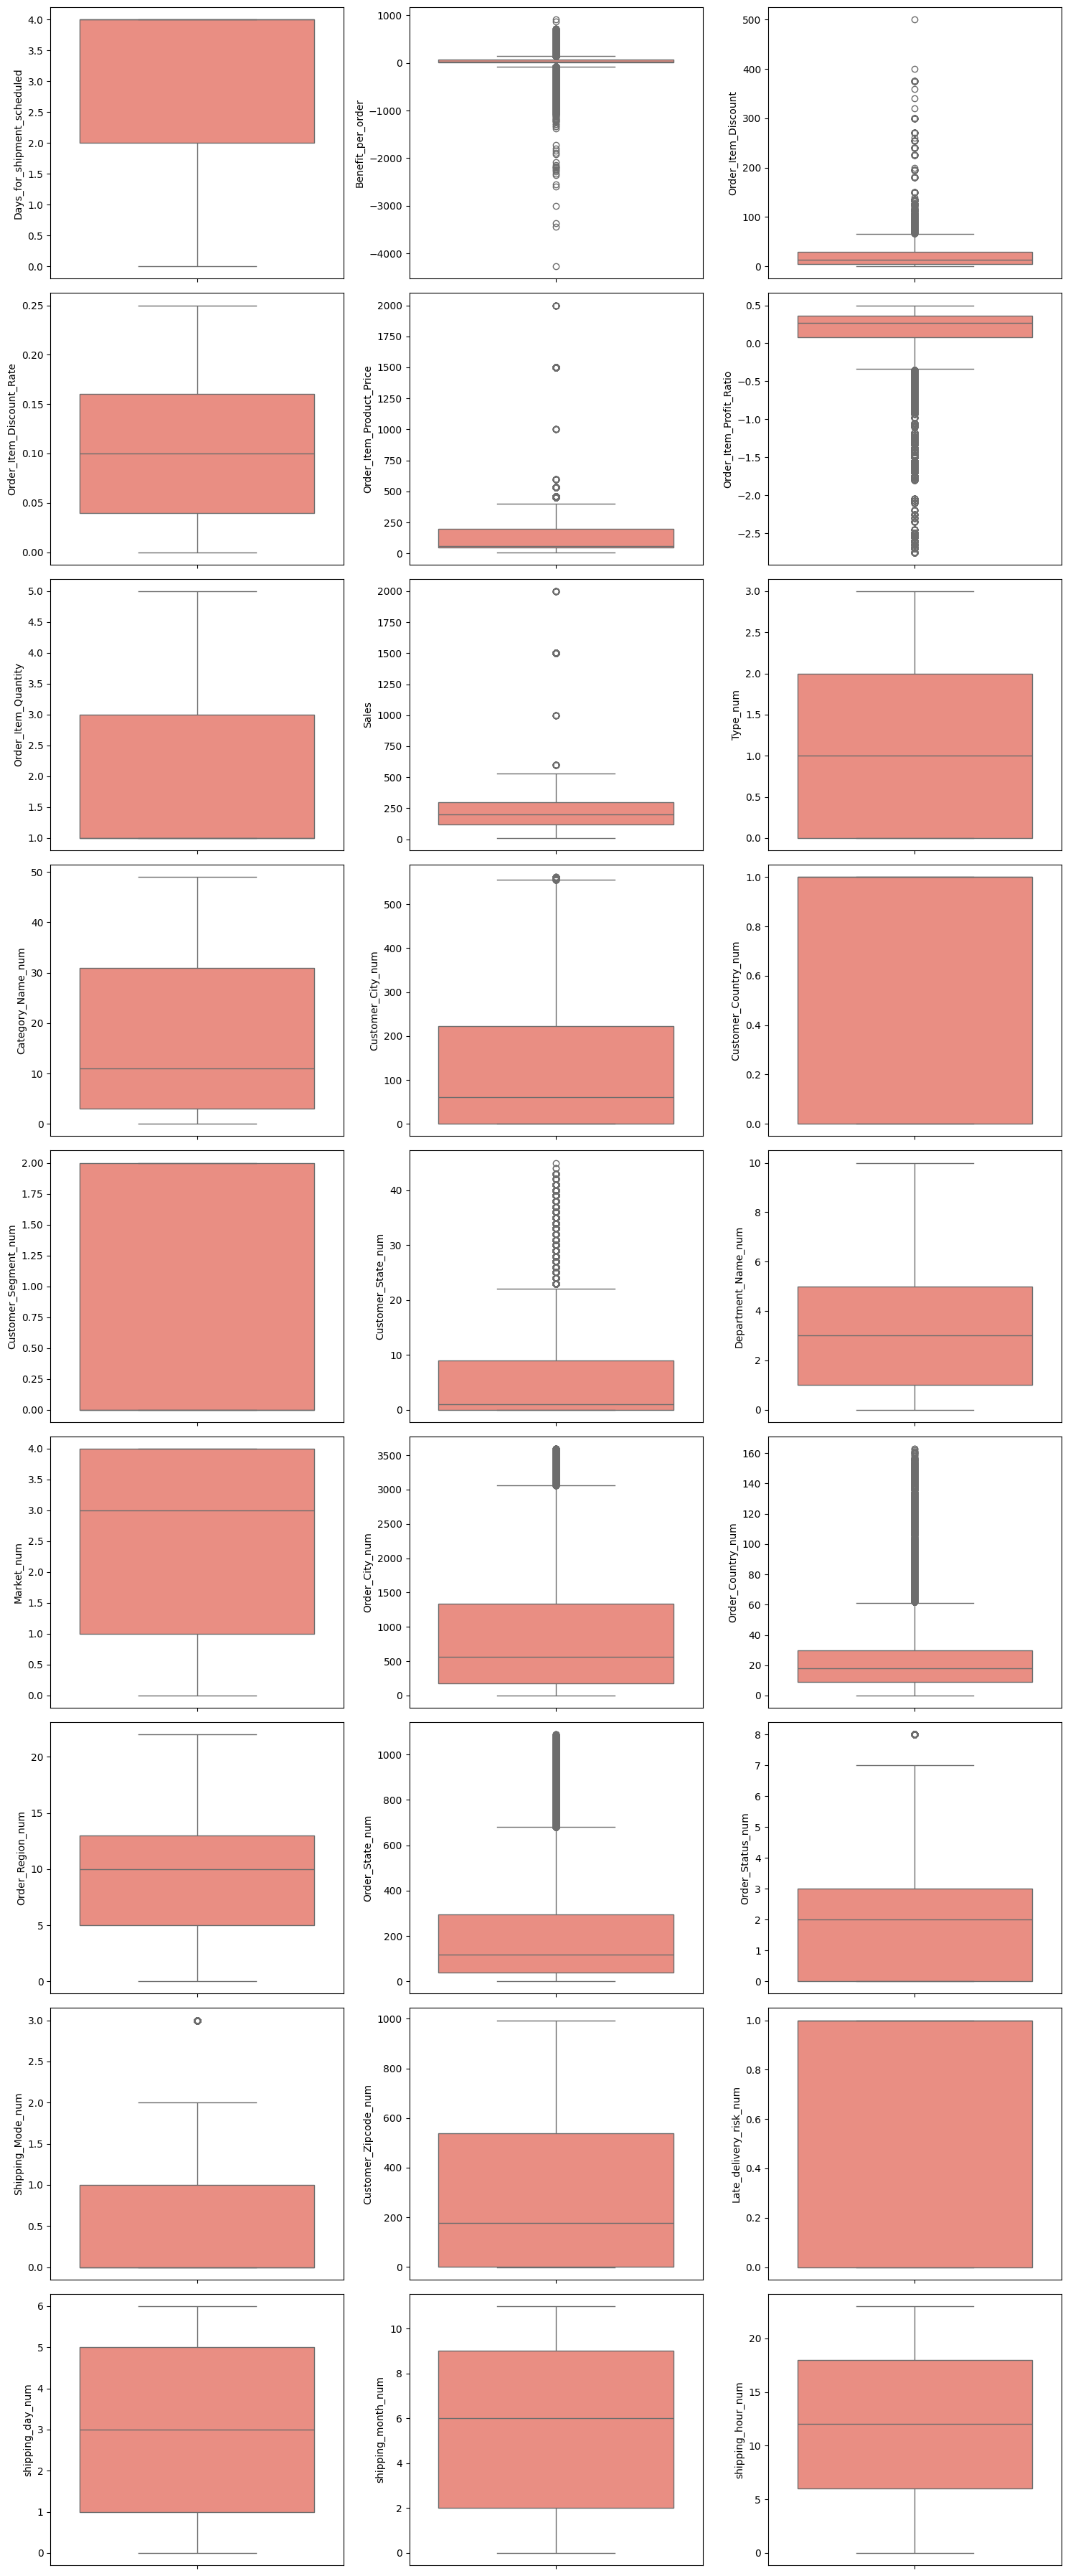

In [3]:
# Creating boxplot to understand the outliers in each variable
ncols = 3
nrows = ut.math.ceil(len(df_final.columns.tolist()) / ncols)
fig, axes = ut.plt.subplots(nrows= nrows, ncols= ncols, figsize= (15, 4 * nrows))

axes = axes.flatten()
for i, col in enumerate(df_final.columns.tolist()):
    ut.sns.boxplot(data= df_final, y= col, ax= axes[i], color= 'salmon')
for j in range(len(df_final.columns.tolist()), len(axes)):
    fig.delaxes(axes[j])

ut.plt.tight_layout()
ut.plt.show()

### 6.1.1 Conclusion Boxplots Charts
* **Priorities Columns for Outliers Limits**:
    - **Benefit_per_order**: The chart shows extreme negatives values which are the losses and extreme possitives.
    - **Order_Item_Discount**: The chart shows a significant spread of outliers. We need to cap this for the model.
    - **Order_Item_Product_Price**: There are items priced far above the mediam.
    - **Order_Item_Profit_Ratio**: There are extreme negatives outliers. A Ration should be within standard range.
    - **Sales**: Heavy concentration of dots at the top.
* **Columns to Leave Alone**:
    - **Days_for_shippment_schedule**: This is a core operational metric. the model need to see the full shipping times.
    - **All _num**: They are not true mathematical outliers.
    - **Late_delivery_risk**: As a rule of thumb, we never touch the target.

In [4]:
# Necessary coding to replace outliers creating upper and lower limits
df_WITH_outliers = df_final.copy()
df_WITHOUT_outliers = df_final.copy()

# Defineing the columns to be treated for outliers.
outliers_cols = ['Benefit_per_order','Order_Item_Discount','Order_Item_Product_Price', 
                 'Order_Item_Profit_Ratio','Sales',] # The target variable can't be modified so we leave as it is.

def replace_outliers(column, data_df):
   col_stats = data_df[column].describe()
   col_iqr = col_stats["75%"] - col_stats["25%"]
   upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
   lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

   if lower_limit < 0: lower_limit = min(data_df[column])
   # Let's take out upper outliers 
   data_df[column] = data_df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
   # Let's take out lower outliers 
   data_df[column] = data_df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
   return data_df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
   df_WITHOUT_outliers, limits = replace_outliers(column, df_WITHOUT_outliers)
   outliers_dict.update({column: limits})

print(f"Outliers Limits: {outliers_dict}") # This jason needs to be saved for future reference. We will use it to replace outliers in the test set and in production.

Outliers Limits: {'Benefit_per_order': [-4274.97998, 151.5], 'Order_Item_Discount': [0.0, 66.87], 'Order_Item_Product_Price': [9.989999771, 424.98], 'Order_Item_Profit_Ratio': [-2.75, 0.78], 'Sales': [9.989999771, 569.91]}


In [5]:
# Saving the json dictionary for outliers limit
with open('../data/interim/outliers_dict.json', 'w') as f:
     ut.json.dump(outliers_dict, f)
print("outliers_dict.json has been saved to data/interim/.")

outliers_dict.json has been saved to data/interim/.


## 6.2 Missing Value Analysis

In [6]:
print("The list below, will show if dataset WITH outliers has any null value for the variables:")
print(df_WITH_outliers.isnull().sum().sort_values(ascending= False))

The list below, will show if dataset WITH outliers has any null value for the variables:
Days_for_shipment_scheduled    0
Benefit_per_order              0
Order_Item_Discount            0
Order_Item_Discount_Rate       0
Order_Item_Product_Price       0
Order_Item_Profit_Ratio        0
Order_Item_Quantity            0
Sales                          0
Type_num                       0
Category_Name_num              0
Customer_City_num              0
Customer_Country_num           0
Customer_Segment_num           0
Customer_State_num             0
Department_Name_num            0
Market_num                     0
Order_City_num                 0
Order_Country_num              0
Order_Region_num               0
Order_State_num                0
Order_Status_num               0
Shipping_Mode_num              0
Customer_Zipcode_num           0
Late_delivery_risk_num         0
shipping_day_num               0
shipping_month_num             0
shipping_hour_num              0
dtype: int64


In [7]:
print("The list below, will show if dataset WITHOUT outliers has any null value for the variables:")
print(df_WITHOUT_outliers.isnull().sum().sort_values(ascending= False))

The list below, will show if dataset WITHOUT outliers has any null value for the variables:
Days_for_shipment_scheduled    0
Benefit_per_order              0
Order_Item_Discount            0
Order_Item_Discount_Rate       0
Order_Item_Product_Price       0
Order_Item_Profit_Ratio        0
Order_Item_Quantity            0
Sales                          0
Type_num                       0
Category_Name_num              0
Customer_City_num              0
Customer_Country_num           0
Customer_Segment_num           0
Customer_State_num             0
Department_Name_num            0
Market_num                     0
Order_City_num                 0
Order_Country_num              0
Order_Region_num               0
Order_State_num                0
Order_Status_num               0
Shipping_Mode_num              0
Customer_Zipcode_num           0
Late_delivery_risk_num         0
shipping_day_num               0
shipping_month_num             0
shipping_hour_num              0
dtype: int64


## 6.3 Inference of New Features
To improve the predictive power of our models for Delivery_Status_num, we created three "Inferred Features." These combine raw data into meaningful supply chain metrics:
1. **Price Per Unit (Sales / Quantity)**:
    - **Rationale**: Differentiates between a high-revenue order caused by a single luxury item versus a large bulk shipment of cheap items.
    - **Benefit**: High-value single items often have different insurance and handling requirements, which can affect delivery speed.
2. **Logistics_Corridor_ID (Spatial Uniqueness)**:
    - **Why**: Using the * 100 multiplier creates a unique numeric ID for every Market-Region combination [cite: 2026-03-02].
    - **Benefit**: A simple addition like Market (5) + Region (12) = 17 is mathematically identical to Market (10) + Region (7) = 17. By using 512 vs. 1007, we ensure the model treats every logistics route as a unique entity with its own specific delay patterns [cite: 2026-03-02].

In [8]:
# Function to apply to both sets
def apply_engineering(df_input):
    df = df_input.copy()
    # Price Per Unit: Differentiates Premium vs. Bulk 
    df['Price_Per_Unit'] = df['Sales'] / (df['Order_Item_Quantity'] + 1e-5)
    
    # Logistics Corridor ID: Unique signature for Market + Region
    # The * 100 ensures Market 5 + Region 12 (512) != Market 6 + Region 6 (606)
    df['Logistics_Corridor_ID'] = (df['Market_num'] * 100) + df['Order_Region_num']
    
    return df

# 1. Apply to BOTH sets so we can compare them later
df_WITH_outliers = apply_engineering(df_WITH_outliers)
df_WITHOUT_outliers = apply_engineering(df_WITHOUT_outliers)

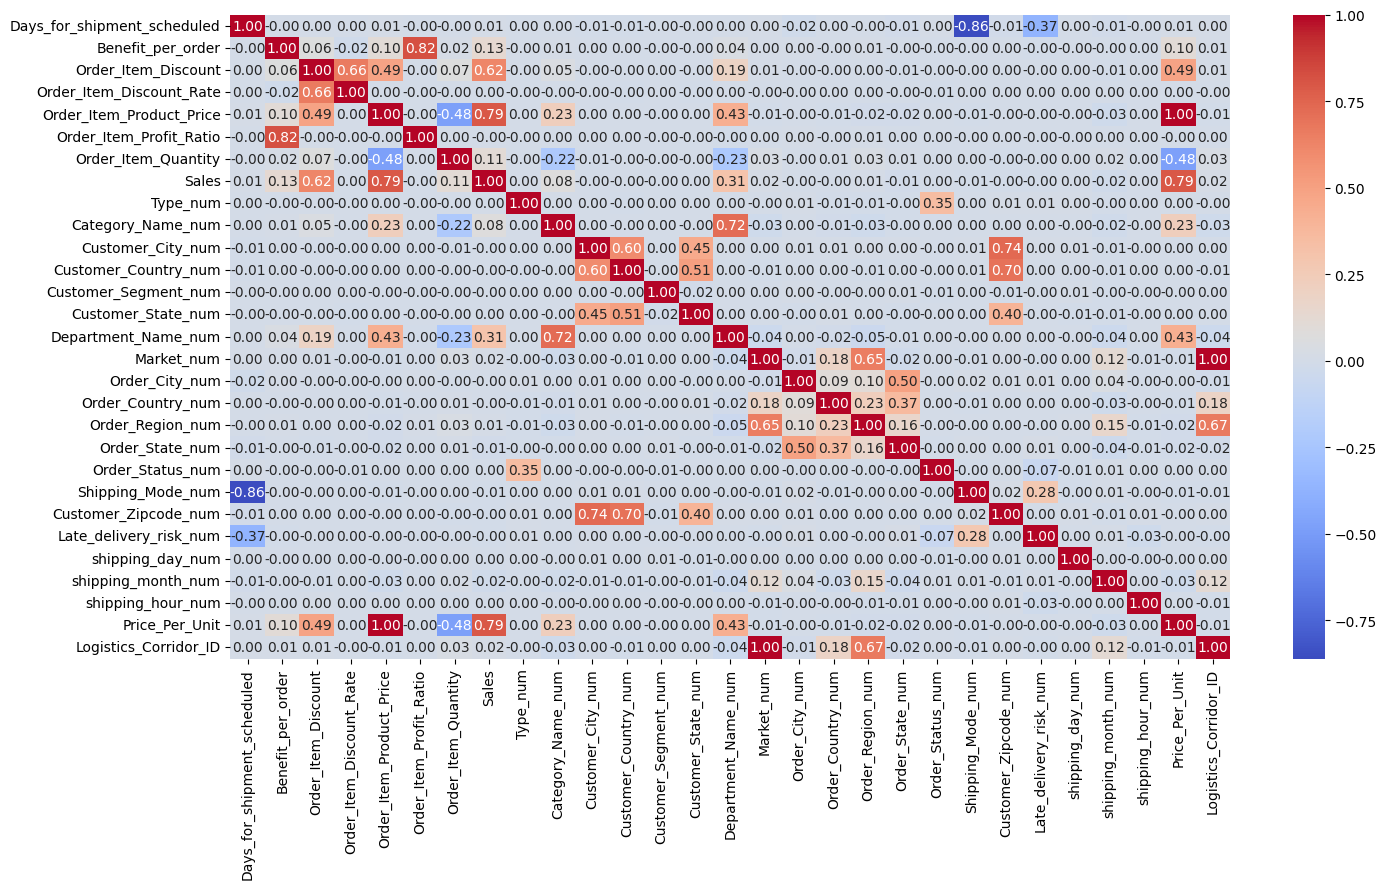

In [9]:
# Creating << NEW >> heatmap chart to analyze complete variables correlation
# cols_num = df_WITH_outliers.select_dtypes(include= ['number']).columns.tolist()
fig, ax = ut.plt.subplots(figsize= (15, 9))
ut.sns.heatmap(df_WITH_outliers.corr(method= "pearson"), annot= True, fmt= ".2f", cmap= "coolwarm", ax= ax).tick_params(axis= 'x', rotation= 90)
ut.plt.tight_layout()
ut.plt.show()

### 6.3.1 Conclusion on Inferenced Features:
- We notice that our new variables maintain a 1-1 ranking with previous variables
- **Price_Per_Unit <-> Order_item_price_product**. We decided to keep the new variable because we consider it more stable.
- **Logistics_Corridor_ID <-> Market_Number**. We decided to keep new variable since it slightly improves the evaluation with other variables.

In [10]:
cols_to_remove = ['Order_Item_Product_Price', 'Market_num', 'Order_Region_num', 'Sales', 'shipping_hour_num'] # We are removing the variable 'Sales' for the moment, to avoid data leakage in the future.

df_WITH_outliers = df_WITH_outliers.drop(columns=cols_to_remove)
df_WITHOUT_outliers = df_WITHOUT_outliers.drop(columns=cols_to_remove)

In [11]:
# Let's check the shape of both sets to see how many rows we have after removing outliers and not necessary predictors.
df_WITH_outliers.shape, df_WITHOUT_outliers.shape

((180519, 24), (180519, 24))

## 6.4 Feature Scaling

In [13]:
# This is the step to divide the set into Train and Test. We will do it for both sets, with and without outliers, to compare the results later on.
# 1. Define predictors and target.		
predictors = ['Days_for_shipment_scheduled', 'Benefit_per_order', 'Order_Item_Discount', 'Order_Item_Discount_Rate', 
              'Order_Item_Profit_Ratio', 'Order_Item_Quantity', 'Type_num', 'Category_Name_num', 
              'Customer_City_num', 'Customer_Country_num', 'Customer_Segment_num', 'Customer_State_num', 'Department_Name_num', 
              'Order_City_num', 'Order_Country_num', 'Order_State_num', 'Order_Status_num', 'Shipping_Mode_num', 'Customer_Zipcode_num',
              'shipping_day_num', 'shipping_month_num', 'Price_Per_Unit','Logistics_Corridor_ID']
target = 'Late_delivery_risk_num'

# 2. Prepare Feature Matrices and Target Vectors.
X_WITH_outliers = df_WITH_outliers.drop(target, axis = 1)[predictors]
X_WITHOUT_outliers = df_WITHOUT_outliers.drop(target, axis = 1)[predictors]
y = df_WITH_outliers[target]

# 3. Perform the Splits.
X_train_WITH_outliers, X_test_WITH_outliers, y_train, y_test = ut.train_test_split(X_WITH_outliers, y, test_size = 0.2, random_state = 10)
X_train_WITHOUT_outliers, X_test_WITHOUT_outliers = ut.train_test_split(X_WITHOUT_outliers, test_size = 0.2, random_state = 10)

# 4. Success Messages.
print("Dataset Devided Successfully!")
print(f"---> WITH OUTLIERS: Train shape: {X_train_WITH_outliers.shape} | Test shape: {X_test_WITH_outliers.shape}")
print(f"---> WITHOUT OUTLIERS: Train shape: {X_train_WITHOUT_outliers.shape} | Test shape: {X_test_WITHOUT_outliers.shape}")
print(f"---> Target (y) distribution in Train set: \n{y_train.value_counts(normalize= True)}")

Dataset Devided Successfully!
---> WITH OUTLIERS: Train shape: (144415, 23) | Test shape: (36104, 23)
---> WITHOUT OUTLIERS: Train shape: (144415, 23) | Test shape: (36104, 23)
---> Target (y) distribution in Train set: 
Late_delivery_risk_num
1    0.547263
0    0.452737
Name: proportion, dtype: float64


In [14]:
# Normalization and MIN_MAX Scaling
# X_train_WITH_outliers 
# X_train_WITHOUT_outliers

# WE NEED TO SAVE 3 OCCURRENCE: 1) DATASET PLANE (WITH NO CHANGES), 2) DATASET NORMALIZED, 3) DATASET MIN-MAX

## NORMALIZATION
### WITH OUTLIERS
norm_WITH_outliers = ut.StandardScaler() # StandardScaler(), used to "normalize" or "resize" your data so that all your features are on the same scale.
# .fit(), The "Learning"
norm_WITH_outliers.fit(X_train_WITH_outliers) # Phase. the scaler (or model) looks at your data and calculates the necessary parameters. It does not change the data; it only learns from it.

# .transform(), The "Applying" Phase.
# NOTE: .fit_transform() — The "Shortcut" --> This is simply a convenience method that does both steps at the same time on the same piece of data. --- Use this on your Training Data ---
X_train_WITH_outliers_norm = norm_WITH_outliers.transform(X_train_WITH_outliers) # This uses the parameters calculated during .fit() to actually modify the data.
X_train_WITH_outliers_norm = ut.pd.DataFrame(X_train_WITH_outliers_norm, index = X_train_WITH_outliers.index, columns = predictors) # We need to convert to DataFrame the transform with this variable
X_test_WITH_outliers_norm = norm_WITH_outliers.transform(X_test_WITH_outliers)
X_test_WITH_outliers_norm = ut.pd.DataFrame(X_test_WITH_outliers_norm, index = X_test_WITH_outliers.index, columns = predictors)

### WITHOUT OUTLIERS
norm_WITHOUT_outliers = ut.StandardScaler()
norm_WITHOUT_outliers.fit(X_train_WITHOUT_outliers)

X_train_WITHOUT_outliers_norm = norm_WITHOUT_outliers.transform(X_train_WITHOUT_outliers)
X_train_WITHOUT_outliers_norm = ut.pd.DataFrame(X_train_WITHOUT_outliers_norm, index = X_train_WITHOUT_outliers.index, columns = predictors)
X_test_WITHOUT_outliers_norm = norm_WITHOUT_outliers.transform(X_test_WITHOUT_outliers)
X_test_WITHOUT_outliers_norm = ut.pd.DataFrame(X_test_WITHOUT_outliers_norm, index = X_test_WITHOUT_outliers.index, columns = predictors)

## SCALED MIN_MAX
### WITH OUTLIERS
scaler_WITH_outliers = ut.MinMaxScaler() # MinMaxScaler() is a scaling technique that transforms the data so that all values fall within a specific range, most commonly between 0 and 1.
scaler_WITH_outliers.fit(X_train_WITH_outliers)

X_train_WITH_outliers_scal = scaler_WITH_outliers.transform(X_train_WITH_outliers)
X_train_WITH_outliers_scal = ut.pd.DataFrame(X_train_WITH_outliers_scal, index = X_train_WITH_outliers.index, columns = predictors)
X_test_WITH_outliers_scal = scaler_WITH_outliers.transform(X_test_WITH_outliers)
X_test_WITH_outliers_scal = ut.pd.DataFrame(X_test_WITH_outliers_scal, index = X_test_WITH_outliers.index, columns = predictors)

### WITHOUT OUTLIERS
scaler_WITHOUT_outliers = ut.MinMaxScaler()
scaler_WITHOUT_outliers.fit(X_train_WITHOUT_outliers)

X_train_WITHOUT_outliers_scal = scaler_WITHOUT_outliers.transform(X_train_WITHOUT_outliers)
X_train_WITHOUT_outliers_scal = ut.pd.DataFrame(X_train_WITHOUT_outliers_scal, index = X_train_WITHOUT_outliers.index, columns = predictors)
X_test_WITHOUT_outliers_scal = scaler_WITHOUT_outliers.transform(X_test_WITHOUT_outliers)
X_test_WITHOUT_outliers_scal = ut.pd.DataFrame(X_test_WITHOUT_outliers_scal, index = X_test_WITHOUT_outliers.index, columns = predictors)

### 6.4.1 Testing Data Consistency

In [15]:
print("Table with train data modified WITH outliers.")
print(ut.tabulate(X_train_WITH_outliers_norm.head(), headers= "keys", tablefmt= "psql"))

Table with train data modified WITH outliers.
+--------+-------------------------------+---------------------+-----------------------+----------------------------+---------------------------+-----------------------+------------+---------------------+---------------------+------------------------+------------------------+----------------------+-----------------------+------------------+---------------------+-------------------+--------------------+---------------------+------------------------+--------------------+----------------------+------------------+-------------------------+
|        |   Days_for_shipment_scheduled |   Benefit_per_order |   Order_Item_Discount |   Order_Item_Discount_Rate |   Order_Item_Profit_Ratio |   Order_Item_Quantity |   Type_num |   Category_Name_num |   Customer_City_num |   Customer_Country_num |   Customer_Segment_num |   Customer_State_num |   Department_Name_num |   Order_City_num |   Order_Country_num |   Order_State_num |   Order_Status_num |   Ship

In [16]:
print("Table with train data modified WITH outliers. Normalization of the data embedded.")
print(ut.tabulate(X_train_WITHOUT_outliers_norm.head(), headers= "keys", tablefmt= "psql"))

Table with train data modified WITH outliers. Normalization of the data embedded.
+--------+-------------------------------+---------------------+-----------------------+----------------------------+---------------------------+-----------------------+------------+---------------------+---------------------+------------------------+------------------------+----------------------+-----------------------+------------------+---------------------+-------------------+--------------------+---------------------+------------------------+--------------------+----------------------+------------------+-------------------------+
|        |   Days_for_shipment_scheduled |   Benefit_per_order |   Order_Item_Discount |   Order_Item_Discount_Rate |   Order_Item_Profit_Ratio |   Order_Item_Quantity |   Type_num |   Category_Name_num |   Customer_City_num |   Customer_Country_num |   Customer_Segment_num |   Customer_State_num |   Department_Name_num |   Order_City_num |   Order_Country_num |   Order_Sta

### 6.4.2 Saving all of the DATASET
- Train, test with all the variance we have created.

In [17]:
# DATASETS that have been created so far in previous steps from the feature engineering
# Save as CSV for speed and performance in Codespaces
# Training Sets
X_train_WITH_outliers.to_csv("../data/processed/X_train_WITH_outliers.csv", index = False)
X_train_WITH_outliers_norm.to_csv("../data/processed/X_train_WITH_outliers_norm.csv", index = False)
X_train_WITH_outliers_scal.to_csv("../data/processed/X_train_WITH_outliers_scal.csv", index = False)
X_train_WITHOUT_outliers.to_csv("../data/processed/X_train_WITHOUT_outliers.csv", index = False)
X_train_WITHOUT_outliers_norm.to_csv("../data/processed/X_train_WITHOUT_outliers_norm.csv", index = False)
X_train_WITHOUT_outliers_scal.to_csv("../data/processed/X_train_WITHOUT_outliers_scal.csv", index = False)

# Testing Sets
X_test_WITH_outliers.to_csv("../data/processed/X_test_WITH_outliers.csv", index = False)
X_test_WITH_outliers_norm.to_csv("../data/processed/X_test_WITH_outliers_norm.csv", index = False)
X_test_WITH_outliers_scal.to_csv("../data/processed/X_test_WITH_outliers_scal.csv", index = False)
X_test_WITHOUT_outliers.to_csv("../data/processed/X_test_WITHOUT_outliers.csv", index = False)
X_test_WITHOUT_outliers_norm.to_csv("../data/processed/X_test_WITHOUT_outliers_norm.csv", index = False)
X_test_WITHOUT_outliers_scal.to_csv("../data/processed/X_test_WITHOUT_outliers_scal.csv", index = False)

# Targets
y_train.to_csv("../data/processed/y_train.csv", index = False)
y_test.to_csv("../data/processed/y_test.csv", index = False)

# SCALERS --> Saving the models

with open("../models/norm_WITH_outliers.pkl", "wb") as file:
  ut.pickle.dump(norm_WITH_outliers, file)
with open("../models/norm_WITHOUT_outliers.pkl", "wb") as file:
  ut.pickle.dump(norm_WITHOUT_outliers, file)
with open("../models/scaler_WITH_outliers.pkl", "wb") as file:
  ut.pickle.dump(scaler_WITH_outliers, file)
with open("../models/scaler_WITHOUT_outliers.pkl", "wb") as file:
  ut.pickle.dump(scaler_WITHOUT_outliers, file)

print("All datasets saved as CSV in record time!")

All datasets saved as CSV in record time!


In [18]:
# Define the file to verify.
file_to_check = "../data/processed/X_train_WITH_outliers_norm.csv"

try:
    # Load the dataset.
    df_verify = ut.pd.read_csv(file_to_check)
    
    # Run Checks.
    print("--- VERIFICATION REPORT ---")
    print(f"File loaded: {file_to_check}")
    print(f"Total Rows: {df_verify.shape[0]}")
    print(f"Total Columns: {df_verify.shape[1]}")
    
    # Verify our specific engineered features.
    expected_features = ['Price_Per_Unit', 'Logistics_Corridor_ID']
    found_features = [f for f in expected_features if f in df_verify.columns]
    
    if len(found_features) == len(expected_features):
        print(f"Engineered Features Found: {found_features}")
    else:
        print("Warning: Missing some engineered features.")

    # Check for NaN values (critical before modeling).
    if df_verify.isnull().sum().sum() == 0:
        print("Data Integrity: 0 missing values found.")
    else:
        print(f"Warning: Found {df_verify.isnull().sum().sum()} missing values.")

except FileNotFoundError:
    print("Error: The file was not found. Check the file path.")

--- VERIFICATION REPORT ---
File loaded: ../data/processed/X_train_WITH_outliers_norm.csv
Total Rows: 144415
Total Columns: 23
Engineered Features Found: ['Price_Per_Unit', 'Logistics_Corridor_ID']
Data Integrity: 0 missing values found.


# Step 7. Feature Selection
**Why we are skipping SelectKBest()**
* While feature selection is often a standard step, we are bypassing SelectKBest for this specific project phase:
    - **Intrinsic Feature Selection**: Random Forest already performs its own internal feature selection by choosing the most informative variables for every split in every tree. Features with low predictive power (such as those with 0.00 correlation in our heatmap) will naturally be ignored by the model.
    - **Preserving Interaction Effects**: SelectKBest evaluates features individually (univariate). This could lead to the accidental removal of engineered features like Price_Per_Unit which might be powerful only when used in combination with other variables.
    - **Post-Model Analysis**: Our strategy is to train with the full set of 24 predictors and then use Feature Importance rankings to prune the model later if necessary, rather than guessing which features to drop beforehand.